# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_4_Perception Model Train & Predict

This notebook trains and applies the *Window View Perception* regression model that maps a window-view image (plus tabular visual features) to a continuous TrueSkill score for each of six perception dimensions: **Prefer, Monotonous, Quiet, Extensive, Vivid, Oppressive**.

Prerequisites: **Code 1** (TrueSkill labels + `TrainingFeatures_*.csv`), **Code 2** (pre-processed images in `data/training_images/WVI_Processed/` and visual features in `Features.csv`).

Pipeline:
1. **Training tables** — load `data/training_features/TrainingFeatures_{dim}.csv` (re-run Code 1 §2.1 if labels change).
2. **Model** — ImageNet **ResNet‑50** (full fine-tuning) + concatenated tabular features → single regression output (MSE loss).
3. **Splits** — compare random vs spatial block K-fold; train hybrid CNN on **spatial** folds.
4. **Ablation** — pathway ablations on spatial folds (reviewer Table 6).
5. **Benchmark & inference** — multi-model comparison and city-scale scoring (spatial checkpoints).

Data sources used in this notebook:
- `data/training_features/TrainingFeatures_{dimension}.csv` (perception score + per-image features)
- `data/training_images/WVI_Processed/` (masked, cropped 256 px images from Code 2)
- `model_outputs/kfold_random/` — existing random-split K-fold (archived, not re-trained)
- `model_outputs/kfold_spatial/` — primary spatial block K-fold checkpoints
- `model_outputs/ablation_spatial/` — ablation runs on spatial folds


## 0. Plotting Configuration

Run plotting configuration first — set up the overall style of figures.

In [2]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
sns.set_palette(OKABE_ITO)

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
PERCEPTION_DIMS_TITLE = [d.capitalize() for d in PERCEPTION_DIMS]
perception_colors = {d: OKABE_ITO[i % len(OKABE_ITO)] for i, d in enumerate(PERCEPTION_DIMS)}
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

TRAINING_IMAGES_DIR = Path("data/training_images")
TRAIN_ORIGINAL_DIR = TRAINING_IMAGES_DIR / "WVI_Original"
TRAIN_IMG_DIR = TRAINING_IMAGES_DIR / "WVI_Processed"
TRAIN_SEGMENTATION_DIR = TRAINING_IMAGES_DIR / "WVI_Segmentation"
FEATURES_DIR = Path("data/training_features")
KFOLD_SPLITS_RANDOM = FEATURES_DIR / "kfold_splits"
KFOLD_SPLITS_SPATIAL = FEATURES_DIR / "kfold_splits_spatial"
MODEL_OUTPUT_ROOT = Path("model_outputs")
MODEL_OUTPUT_RANDOM = MODEL_OUTPUT_ROOT / "kfold_random"
MODEL_OUTPUT_SPATIAL = MODEL_OUTPUT_ROOT / "kfold_spatial"
MODEL_OUTPUT_ABLATION = MODEL_OUTPUT_ROOT / "ablation_spatial"
USE_FROZEN_KFOLD_SPLITS = True


## 1. Training Feature Tables

The per-dimension training tables produced in Code 1 contain `ID`, the TrueSkill `Score` for that dimension, eleven semantic-segmentation ratios (sky, building, tree, …), `Floor`, and twelve color/texture descriptors.  Below we summarise the regression target distribution and feature ranges used during training.

In [20]:
import pandas as pd

training_tables = {dim: pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv") for dim in PERCEPTION_DIMS}
example = training_tables["oppressive"]
print(f"TrainingFeatures_oppressive.csv shape: {example.shape}")
print("Columns:")
print(list(example.columns))

score_summary = pd.concat({dim: t[dim].describe() for dim, t in training_tables.items()}, axis=1)
print("\nTrueSkill score summary across dimensions:")
print(score_summary.round(3).to_string())

# Descriptive statistics of the tabular model features (identical across dimensions)
_semantic_cols = [
    "Sky", "High rise building", "Low rise building", "Grass", "Hard ground",
    "Tree", "Water", "Railing", "Road", "Barren land", "Building interior",
]
_colour_cols = [
    "Hue_Mean", "Hue_Std", "Saturation_Mean", "Saturation_Std",
    "Brightness_Mean", "Brightness_Std", "EdgePixelRatio", "Entropy",
    "Colorfulness", "Contrast", "Sharpness", "Image_Variance",
]
_floor_cols = ["Floor"]

for _group_name, _cols in [("Semantic", _semantic_cols), ("Colour", _colour_cols), ("Floor", _floor_cols)]:
    _present = [c for c in _cols if c in example.columns]
    _feat_summary = example[_present].agg(["mean", "std", "min", "max"]).T
    print(f"\n{_group_name} feature summary (n={len(example)}):")
    print(_feat_summary.round(4).to_string())

TrainingFeatures_oppressive.csv shape: (499, 26)
Columns:
['ID', 'oppressive', 'Sky', 'High rise building', 'Low rise building', 'Grass', 'Hard ground', 'Tree', 'Water', 'Railing', 'Road', 'Barren land', 'Building interior', 'Floor', 'Hue_Mean', 'Hue_Std', 'Saturation_Mean', 'Saturation_Std', 'Brightness_Mean', 'Brightness_Std', 'EdgePixelRatio', 'Entropy', 'Colorfulness', 'Contrast', 'Sharpness', 'Image_Variance']

TrueSkill score summary across dimensions:
        prefer  monotonous    quiet  extensive    vivid  oppressive
count  499.000     499.000  499.000    499.000  499.000     499.000
mean     2.500       2.500    2.500      2.500    2.500       2.500
std      1.448       1.448    1.448      1.448    1.448       1.448
min      0.000       0.000    0.000      0.000    0.000       0.000
25%      1.250       1.250    1.250      1.250    1.250       1.250
50%      2.500       2.500    2.500      2.500    2.500       2.500
75%      3.750       3.750    3.750      3.750    3.750      

## 2. Random vs spatial K-fold splits

Frozen splits from **Code 3** on the same 499 training IDs:

| Scheme | Manifest | Holdout |
|--------|----------|--------|
| Random stratified | `kfold_splits/` | Image-level |
| Spatial block | `kfold_splits_spatial/` | Whole `Hexagon_ID` |

Random vs spatial **test R²** comparison runs at the end of **§5** (`show_random_vs_spatial_comparisons`).


In [5]:
LEAKAGE_CSV = KFOLD_SPLITS_SPATIAL / "spatial_vs_random_leakage.csv"
if LEAKAGE_CSV.exists():
    leak = pd.read_csv(LEAKAGE_CSV)
    print("Train∩test hexagon overlap per fold:")
    display(leak.groupby("split_type")["n_overlap_hex"].agg(["mean", "min", "max"]))
    display(
        leak.pivot_table(index=["dim", "fold"], columns="split_type", values="n_overlap_hex").head(10)
    )
else:
    print(f"Missing {LEAKAGE_CSV} — run Code 3 spatial K-fold cell.")


Train∩test hexagon overlap per fold:


,mean,min,max
split_type,,,
random_stratified,46.466667,38,55
spatial_block,0.000000,0,0


split_type       random_stratified  spatial_block
dim        fold                                  
extensive  1                  47.0            0.0
           2                  45.0            0.0
           3                  52.0            0.0
           4                  48.0            0.0
           5                  41.0            0.0
monotonous 1                  55.0            0.0
           2                  38.0            0.0
           3                  42.0            0.0
           4                  50.0            0.0
           5                  49.0            0.0

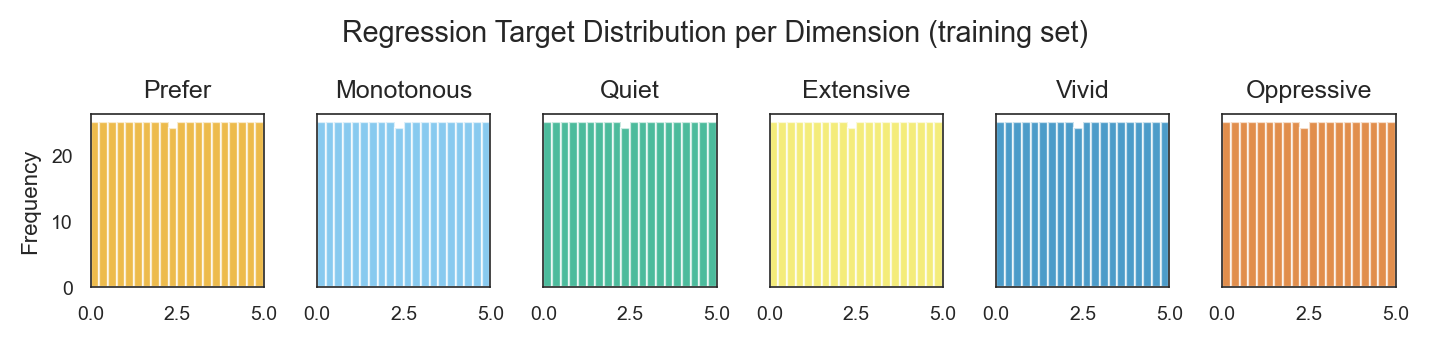

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_SMALL))
fig.suptitle("Regression Target Distribution per Dimension (training set)", y=0.85)
for ax, dim in zip(axes, PERCEPTION_DIMS):
    target = training_tables[dim][dim].dropna()
    ax.hist(target, bins=20, alpha=0.7, color=perception_colors[dim])
    ax.set_title(dim.capitalize())
    ax.set_xlim(0, 5)
    ax.set_box_aspect(1)
axes[0].set_ylabel("Frequency")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)
plt.tight_layout()
savefig_all(fig, "figures/code3_target_distribution")
plt.show()

## 3. Model architecture

ImageNet **ResNet-50** (fine-tuned) + tabular features → regression head. §6 ablations toggle CNN / semantic / colour pathways (`ABLATION_CONFIGS`).


In [7]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

SEMANTIC_COLS = [
    "Sky", "High rise building", "Low rise building", "Grass", "Hard ground",
    "Tree", "Water", "Railing", "Road", "Barren land", "Building interior",
]
COLOUR_COLS = [
    "Hue_Mean", "Hue_Std", "Saturation_Mean", "Saturation_Std",
    "Brightness_Mean", "Brightness_Std", "EdgePixelRatio", "Entropy",
    "Colorfulness", "Contrast", "Sharpness", "Image_Variance",
]
TABULAR_FLOOR = ["Floor"]


def ablation_aux_cols(*, semantic: bool = False, colour: bool = False, floor: bool = False) -> list[str]:
    """Build tabular feature list for ablation configs."""
    cols: list[str] = []
    if semantic:
        cols.extend(SEMANTIC_COLS)
    if colour:
        cols.extend(COLOUR_COLS)
    if floor:
        cols.extend(TABULAR_FLOOR)
    return cols


# Floor: included in all tabular / hybrid configs that match the production model,
# except explicit *_no_floor variants (isolates semantic/colour without elevation).
ABLATION_CONFIGS = {
    # --- Reviewer core (response-1.tex) ---
    "resnet50_only": {
        "label": "ResNet-50 only",
        "use_image": True,
        "aux_cols": [],
        "train_in_ablation": True,
    },
    "semantic_only": {
        "label": "Semantic + Floor (Ridge)",
        "use_image": False,
        "aux_cols": ablation_aux_cols(semantic=True, floor=True),
        "train_in_ablation": True,
    },
    "resnet50_semantic": {
        "label": "ResNet-50 + Semantic + Floor",
        "use_image": True,
        "aux_cols": ablation_aux_cols(semantic=True, floor=True),
        "train_in_ablation": True,
    },
    "full": {
        "label": "Full (ResNet-50 + Semantic + Colour + Floor)",
        "use_image": True,
        "aux_cols": ablation_aux_cols(semantic=True, colour=True, floor=True),
        "train_in_ablation": False,  # trained in §5 → MODEL_OUTPUT_SPATIAL
    },
    # --- Colour / combined pathways ---
    "colour_only": {
        "label": "Colour + Floor (Ridge)",
        "use_image": False,
        "aux_cols": ablation_aux_cols(colour=True, floor=True),
        "train_in_ablation": True,
    },
    "semantic_colour": {
        "label": "Semantic + Colour + Floor (Ridge)",
        "use_image": False,
        "aux_cols": ablation_aux_cols(semantic=True, colour=True, floor=True),
        "train_in_ablation": True,
    },
    "resnet50_colour": {
        "label": "ResNet-50 + Colour + Floor",
        "use_image": True,
        "aux_cols": ablation_aux_cols(colour=True, floor=True),
        "train_in_ablation": True,
    },
    "resnet50_semantic_colour": {
        "label": "ResNet-50 + Semantic + Colour + Floor",
        "use_image": True,
        "aux_cols": ablation_aux_cols(semantic=True, colour=True, floor=True),
        "train_in_ablation": False,  # same features as full; metrics from MODEL_OUTPUT_SPATIAL
    },
    # --- Floor ablation (optional) ---
    "resnet50_semantic_colour_no_floor": {
        "label": "ResNet-50 + Semantic + Colour (no Floor)",
        "use_image": True,
        "aux_cols": ablation_aux_cols(semantic=True, colour=True, floor=False),
        "train_in_ablation": True,
    },
}

ABLATION_TRAIN_ORDER = [
    "resnet50_only",
    "semantic_only",
    "colour_only",
    "semantic_colour",
    "resnet50_semantic",
    "resnet50_colour",
    "resnet50_semantic_colour_no_floor",
    "full",
]


def aux_columns_for_config(config_key: str, all_columns, dim: str) -> list[str]:
    allowed = set(ABLATION_CONFIGS[config_key]["aux_cols"])
    return [c for c in training_aux_feature_columns(all_columns, dim) if c in allowed]


def ablation_trainable_keys() -> list[str]:
    return [k for k in ABLATION_TRAIN_ORDER if ABLATION_CONFIGS[k].get("train_in_ablation", True)]


def ablation_output_dir(config_key: str) -> Path:
    if config_key in ("full", "resnet50_semantic_colour"):
        return MODEL_OUTPUT_SPATIAL
    return MODEL_OUTPUT_ABLATION / config_key


def ablation_dims_complete(output_dir: Path, dims: list[str]) -> bool:
    return output_dir.is_dir() and all((output_dir / f"kfold_cv_{d}.csv").exists() for d in dims)


def is_tabular_ridge_ablation(config_key: str) -> bool:
    """Pure tabular ablation configs use Ridge (same as §7 benchmark), not TabularRegressor."""
    return not ABLATION_CONFIGS[config_key]["use_image"]


def _tabular_ablation_is_ridge_csv(path: Path) -> bool:
    if not path.exists():
        return False
    df = pd.read_csv(path)
    return "backend" in df.columns and (df["backend"] == "ridge").all()


def ablation_config_complete(out_dir: Path, config_key: str, dims: list[str]) -> bool:
    if not ablation_dims_complete(out_dir, dims):
        return False
    if is_tabular_ridge_ablation(config_key):
        return all(_tabular_ablation_is_ridge_csv(out_dir / f"kfold_cv_{d}.csv") for d in dims)
    return True


class WindowSceneRegressor(nn.Module):
    def __init__(self, num_aux_features: int, dropout: float = 0.5):
        super().__init__()
        self.num_aux = num_aux_features
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        cnn_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        in_dim = cnn_dim + max(num_aux_features, 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, 1),
        )

    def forward(self, image, aux):
        feats = self.backbone(image)
        if self.num_aux > 0:
            feats = torch.cat((feats, aux), dim=1)
        return self.head(feats).squeeze(-1)


class TabularRegressor(nn.Module):
    def __init__(self, num_aux_features: int, dropout: float = 0.5):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(num_aux_features, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, 1),
        )

    def forward(self, image, aux):
        return self.head(aux).squeeze(-1)


def build_regressor(config_key: str, num_aux_features: int) -> nn.Module:
    return (
        WindowSceneRegressor(num_aux_features)
        if ABLATION_CONFIGS[config_key]["use_image"]
        else TabularRegressor(num_aux_features)
    )


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def load_model(num_aux_features: int, config_key: str = "full") -> nn.Module:
    return build_regressor(config_key, num_aux_features)


n_aux_full = len(aux_columns_for_config("full", training_tables["oppressive"].columns, "oppressive"))
demo_model = load_model(n_aux_full, "full")
print(f"Full-model tabular features: {n_aux_full}")
print(f"Trainable params (full): {count_trainable_parameters(demo_model):,}")
print(f"Ablation trainable configs: {ablation_trainable_keys()}")


Full-model tabular features: 24
Trainable params (full): 24,569,921
Ablation trainable configs: ['resnet50_only', 'semantic_only', 'colour_only', 'semantic_colour', 'resnet50_semantic', 'resnet50_colour', 'resnet50_semantic_colour_no_floor']


## 4. Dataset and training setup

Each example: 256 px WVI + scaled tabular features → TrueSkill score.


In [8]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


class WindowScenesDataset(Dataset):
    def __init__(
        self,
        image_dir,
        score_csv,
        indices,
        labels,
        transform=None,
        aux_features: np.ndarray | None = None,
        load_images: bool = True,
    ):
        self.image_dir = Path(image_dir)
        self.df = pd.read_csv(score_csv).iloc[indices].reset_index(drop=True)
        self.labels = list(labels)
        self.transform = transform
        self.aux_features = aux_features
        self.load_images = load_images

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.load_images:
            img_id = self.df.iloc[idx, 0]
            image = Image.open(self.image_dir / f"{img_id}.jpg").convert("RGB")
            if self.transform:
                image = self.transform(image)
        else:
            image = torch.zeros(3, 224, 224)
        if self.aux_features is not None:
            aux = torch.tensor(self.aux_features[idx], dtype=torch.float32)
        else:
            aux = torch.tensor(self.df.iloc[idx, 2:].values.astype(np.float32))
        target = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, aux, target


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## 5. Training helpers & spatial K-fold



In [9]:
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score


def _mean_std(values) -> tuple[float, float]:
    """Sample mean and std (ddof=1) across K-fold test metrics."""
    s = pd.Series(values, dtype=float)
    return float(s.mean()), float(s.std(ddof=1))


def fmt_mean_std(mean: float, std: float, nd: int = 4) -> str:
    return f"{mean:.{nd}f}±{std:.{nd}f}"


def write_metrics_txt(
    path: Path,
    best_epoch: int,
    train_m: dict,
    val_m: dict,
    test_m: dict,
) -> None:
    """Write best-checkpoint metrics in the format used by §4 / Code 5."""
    lines = [
        f"Best Model Metrics (Epoch {best_epoch}; selected by validation R²):",
        (
            f"Train - Loss: {train_m['loss']:.4f}, R2: {train_m['r2']:.4f}, "
            f"MSE: {train_m['mse']:.4f}, MAE: {train_m['mae']:.4f}, RMSE: {train_m['rmse']:.4f}"
        ),
        f"Train - R2 Tolerance 2: {train_m['r2_tol2']:.4f}",
        (
            f"Validation - Loss: {val_m['loss']:.4f}, R2: {val_m['r2']:.4f}, "
            f"MSE: {val_m['mse']:.4f}, MAE: {val_m['mae']:.4f}, RMSE: {val_m['rmse']:.4f}"
        ),
        f"Validation - R2 Tolerance 2: {val_m['r2_tol2']:.4f}",
        (
            f"Test - Loss: {test_m['loss']:.4f}, R2: {test_m['r2']:.4f}, "
            f"MSE: {test_m['mse']:.4f}, MAE: {test_m['mae']:.4f}, RMSE: {test_m['rmse']:.4f}"
        ),
        f"Test - R2 Tolerance 2: {test_m['r2_tol2']:.4f}",
        "",
    ]
    path.write_text("\n".join(lines), encoding="utf-8")


def categorize(scores, n_bins):
    return pd.cut(scores, bins=n_bins, labels=False)

def classification_metrics(y_true, y_pred, n_bins):
    a = categorize(y_true, n_bins)
    b = categorize(y_pred, n_bins)
    return (
        accuracy_score(a, b),
        precision_score(a, b, average="weighted", zero_division=0),
        recall_score(a, b, average="weighted", zero_division=0),
        f1_score(a, b, average="weighted", zero_division=0),
    )

def tolerance_r2(y_true, y_pred, tol):
    adj = [p if abs(p - y) > tol else y for p, y in zip(y_pred, y_true)]
    return r2_score(y_true, adj)

def run_epoch(loader, model, criterion, optimizer, device, train: bool):
    model.train(train)
    losses, preds, labels = [], [], []
    for batch in loader:
        if batch is None:
            continue
        images, aux, target = (b.to(device) for b in batch)
        with torch.set_grad_enabled(train):
            out = model(images, aux)
            target = target.float().view(-1)
            out = out.view(-1)
            loss = criterion(out, target)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
        preds.extend(out.detach().cpu().numpy().ravel().tolist())
        labels.extend(target.detach().cpu().numpy().ravel().tolist())
    metrics = {
        "loss": float(np.mean(losses)),
        "r2": r2_score(labels, preds),
        "r2_tol2": tolerance_r2(labels, preds, 2),
        "mse": mean_squared_error(labels, preds),
        "mae": float(np.mean(np.abs(np.array(labels) - np.array(preds)))),
        "rmse": float(np.sqrt(mean_squared_error(labels, preds))),
    }
    for n_bins in (5, 3, 2):
        acc, prec, rec, f1 = classification_metrics(labels, preds, n_bins)
        metrics[f"acc_{n_bins}c"] = acc
        metrics[f"f1_{n_bins}c"] = f1
    return metrics

#### Training (spatial block K-fold — primary)

**Splits:** `KFOLD_SPLITS_SPATIAL` / `kfold_splits_spatial/` (Code 3).  
**Outputs:** `MODEL_OUTPUT_SPATIAL` (`model_outputs/kfold_spatial/`).

`RUN_SPATIAL_KFOLD = True` trains the **full** hybrid model. Set `False` if `kfold_cv_summary.csv` already exists.  
Random-split CNN results are read from `MODEL_OUTPUT_RANDOM` only (§2); not re-trained.

**Ablations** (reviewer request): §6 trains `resnet50_only`, `semantic_only`, `resnet50_semantic`, `full` on the same spatial folds → `MODEL_OUTPUT_ABLATION/`.



=== Spatial K-fold prefer (1/6) ===
[prefer] skip — exists model_outputs/kfold_spatial/kfold_cv_prefer.csv

=== Spatial K-fold monotonous (2/6) ===
[monotonous] skip — exists model_outputs/kfold_spatial/kfold_cv_monotonous.csv

=== Spatial K-fold quiet (3/6) ===
[quiet] skip — exists model_outputs/kfold_spatial/kfold_cv_quiet.csv

=== Spatial K-fold extensive (4/6) ===
[extensive] skip — exists model_outputs/kfold_spatial/kfold_cv_extensive.csv

=== Spatial K-fold vivid (5/6) ===
[vivid] skip — exists model_outputs/kfold_spatial/kfold_cv_vivid.csv

=== Spatial K-fold oppressive (6/6) ===
[oppressive] skip — exists model_outputs/kfold_spatial/kfold_cv_oppressive.csv

=== Spatial K-fold summary ===


,dimension,test_r2_mean,test_r2_std,test_mse_mean,test_mse_std,test_rmse_mean,test_rmse_std
0,prefer,0.748246,0.022069,0.524689,0.025531,0.724181,0.017727
1,monotonous,0.490566,0.078658,1.074886,0.354689,1.025384,0.171293
2,quiet,0.504844,0.060989,1.035904,0.116894,1.016444,0.058582
3,extensive,0.689688,0.045040,0.646381,0.089816,0.802378,0.056688
4,vivid,0.561987,0.080973,0.881904,0.118179,0.937435,0.062441
5,oppressive,0.643436,0.096752,0.729295,0.143758,0.850707,0.083616



=== Full hybrid CNN (random vs spatial) ===


split_scheme,random_stratified,spatial_block
dimension,,
prefer,0.7578,0.7482
monotonous,0.4851,0.4906
quiet,0.5047,0.5048
extensive,0.7072,0.6897
vivid,0.6281,0.5620
oppressive,0.6494,0.6434


,random − spatial
dimension,
prefer,0.0095
monotonous,-0.0055
quiet,-0.0002
extensive,0.0175
vivid,0.0661
oppressive,0.0060


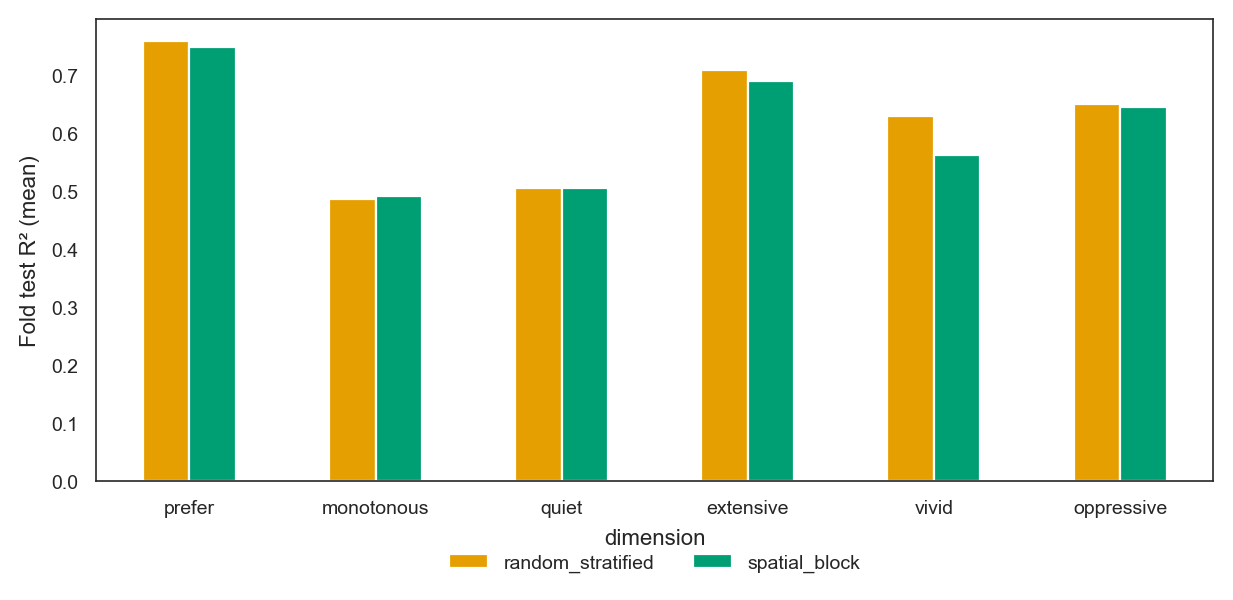


=== Multi-model benchmark — Hybrid row (random vs spatial) ===


split_scheme,random_stratified,spatial_block
dimension,,
prefer,0.7578,0.7482
monotonous,0.4851,0.4906
quiet,0.5047,0.5048
extensive,0.7072,0.6897
vivid,0.6281,0.5620
oppressive,0.6494,0.6434


,random − spatial
dimension,
prefer,0.0095
monotonous,-0.0055
quiet,-0.0002
extensive,0.0175
vivid,0.0661
oppressive,0.0060



=== Tabular + hybrid — random − spatial ΔR² (mean test R²) ===


,mean ΔR² (random−spatial)
model,
Ridge,0.0142
Lasso,0.0240
ElasticNet,0.0211
PLS,0.0139
RandomForest,0.0180
SVR,0.0069
XGBoost,0.0219
Hybrid Neural Network,0.0156


In [19]:
import json
import time
import torch.optim as optim
import joblib
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.6, 0.2, 0.2
MAX_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10
SPLIT_SEED = 42
N_FOLDS = 5
SCORE_BIN_LABELS = ["[0,1)", "[1,2)", "[2,3)", "[3,4)", "[4,5]"]
VAL_FRAC_WITHIN_TRAIN_POOL = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)


def score_stratum(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    return np.clip(np.floor(y).astype(int), 0, len(SCORE_BIN_LABELS) - 1)


def stratified_train_val_test_indices(
    y: np.ndarray,
    train_frac: float = TRAIN_FRAC,
    val_frac: float = VAL_FRAC,
    test_frac: float = TEST_FRAC,
    seed: int = SPLIT_SEED,
) -> tuple[list[int], list[int], list[int]]:
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-6:
        raise ValueError("train_frac + val_frac + test_frac must equal 1")
    y = np.asarray(y, dtype=float)
    strata = score_stratum(y)
    idx = np.arange(len(y))
    idx_trainval, idx_test = train_test_split(
        idx, test_size=test_frac, stratify=strata, random_state=seed
    )
    rel_val = val_frac / (train_frac + val_frac)
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=rel_val,
        stratify=strata[idx_trainval],
        random_state=seed,
    )
    return sorted(idx_train.tolist()), sorted(idx_val.tolist()), sorted(idx_test.tolist())


def stratified_kfold_train_val_test_splits(
    y: np.ndarray, n_folds: int = N_FOLDS, seed: int = SPLIT_SEED
) -> list[tuple[list[int], list[int], list[int]]]:
    y = np.asarray(y, dtype=float)
    strata = score_stratum(y)
    idx = np.arange(len(y))
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_i, (tr_rel, te_rel) in enumerate(skf.split(idx, strata), start=1):
        test_idx = idx[te_rel]
        trainval_idx = idx[tr_rel]
        rel = np.arange(len(trainval_idx))
        tr_rel_in, va_rel_in = train_test_split(
            rel,
            test_size=VAL_FRAC_WITHIN_TRAIN_POOL,
            stratify=strata[trainval_idx],
            random_state=seed + fold_i,
        )
        folds.append(
            (
                sorted(trainval_idx[tr_rel_in].tolist()),
                sorted(trainval_idx[va_rel_in].tolist()),
                sorted(test_idx.tolist()),
            )
        )
    return folds


def print_stratified_split_summary(dim: str, y: np.ndarray, train_idx, val_idx, test_idx) -> None:
    strata = score_stratum(y)
    print(
        f"[{dim}] stratified split (seed={SPLIT_SEED}): "
        f"train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}",
        flush=True,
    )
    for label, sid in {"train": train_idx, "val": val_idx, "test": test_idx}.items():
        counts = pd.Series(strata[sid]).value_counts().sort_index()
        parts = [f"{SCORE_BIN_LABELS[i]}:{counts.get(i, 0)}" for i in range(len(SCORE_BIN_LABELS))]
        print(f"  {label:5s} " + ", ".join(parts), flush=True)


def _load_frozen_kfold_manifest(dim: str, splits_dir: Path) -> dict | None:
    path = splits_dir / f"kfold_split_{dim}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def frozen_stratify_y_from_manifest(manifest: dict, df: pd.DataFrame) -> np.ndarray:
    lut = {s["ID"]: float(s["score"]) for s in manifest["samples"]}
    return np.array([lut[str(i)] for i in df["ID"].astype(str)], dtype=float)


def align_frozen_kfold_folds(manifest: dict, df: pd.DataFrame) -> list[tuple[list[int], list[int], list[int]]]:
    lookup = {str(i): idx for idx, i in enumerate(df["ID"].astype(str))}
    frozen_ids = {s["ID"] for s in manifest["samples"]}
    if set(lookup) != frozen_ids:
        raise ValueError(
            f"[{manifest['dim']}] ID set mismatch vs frozen splits "
            f"(missing={len(frozen_ids - set(lookup))}, extra={len(set(lookup) - frozen_ids)})"
        )
    return [
        (
            sorted(lookup[i] for i in fold["train_ids"]),
            sorted(lookup[i] for i in fold["val_ids"]),
            sorted(lookup[i] for i in fold["test_ids"]),
        )
        for fold in manifest["folds"]
    ]


def collate_skipping_none(batch):
    batch = [b for b in batch if b is not None]
    return torch.utils.data.dataloader.default_collate(batch) if batch else None


def _fit_train_eval_fold(
    dim: str,
    df: pd.DataFrame,
    y: np.ndarray,
    aux_cols: list[str],
    train_idx: list[int],
    val_idx: list[int],
    test_idx: list[int],
    fold_i: int,
    n_folds: int,
    device: torch.device,
    n_epochs: int,
    early_stopping_patience: int,
    batch_size: int,
    seed: int,
    config_key: str = "full",
) -> tuple[dict, dict, dict, int, dict | None, StandardScaler | None]:
    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    use_image = ABLATION_CONFIGS[config_key]["use_image"]
    n_aux = len(aux_cols)
    if n_aux:
        aux_raw = df[aux_cols].values.astype(np.float64)
        aux_scaler = StandardScaler()
        aux_scaler.fit(aux_raw[train_idx])
        aux_scaled = aux_scaler.transform(aux_raw).astype(np.float32)
    else:
        aux_scaler = None
        aux_scaled = np.zeros((len(df), 0), dtype=np.float32)

    def _loader(indices, labels, transform, shuffle):
        aux_batch = aux_scaled[indices] if n_aux else np.zeros((len(indices), 0), dtype=np.float32)
        return DataLoader(
            WindowScenesDataset(
                TRAIN_IMG_DIR,
                score_csv,
                indices,
                labels,
                transform,
                aux_batch,
                load_images=use_image,
            ),
            batch_size=batch_size,
            shuffle=shuffle,
            generator=torch.Generator().manual_seed(seed + fold_i) if shuffle else None,
            collate_fn=collate_skipping_none,
        )

    train_loader = _loader(train_idx, y[train_idx], train_transform, True)
    val_loader = _loader(val_idx, y[val_idx], eval_transform, False)
    test_loader = _loader(test_idx, y[test_idx], eval_transform, False)

    model = build_regressor(config_key, n_aux).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_r2, best_epoch, best_state = -np.inf, 0, None
    epochs_no_improve = 0
    t0 = time.time()

    for epoch in range(n_epochs):
        train_metrics = run_epoch(train_loader, model, criterion, optimizer, device, train=True)
        val_metrics = run_epoch(val_loader, model, criterion, optimizer, device, train=False)
        scheduler.step()
        if val_metrics["r2"] > best_val_r2:
            best_val_r2 = val_metrics["r2"]
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epoch % 5 == 0 or epochs_no_improve == 0:
            print(
                f"  [{dim}|{config_key}] f{fold_i}/{n_folds} ep {epoch+1:02d} "
                f"({(time.time()-t0)/60:.1f}m) train R²={train_metrics['r2']:+.3f} val R²={val_metrics['r2']:+.3f}",
                flush=True,
            )
        if early_stopping_patience > 0 and epochs_no_improve >= early_stopping_patience:
            print(f"  [{dim}] fold {fold_i} early stop @ ep {epoch + 1}", flush=True)
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    train_m = run_epoch(train_loader, model, criterion, optimizer, device, train=False)
    val_m = run_epoch(val_loader, model, criterion, optimizer, device, train=False)
    test_m = run_epoch(test_loader, model, criterion, optimizer, device, train=False)
    return train_m, val_m, test_m, best_epoch, best_state, aux_scaler


def train_dimension_kfold(
    dim: str,
    splits_dir: Path,
    output_dir: Path,
    config_key: str = "full",
    scheme_label: str = "spatial_block",
    n_folds: int = N_FOLDS,
    n_epochs: int = MAX_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    batch_size: int = 8,
    seed: int = SPLIT_SEED,
    skip_if_summary_exists: bool = True,
) -> pd.DataFrame:
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_path = output_dir / "kfold_cv_summary.csv"
    per_dim_path = output_dir / f"kfold_cv_{dim}.csv"
    if skip_if_summary_exists and per_dim_path.exists():
        print(f"[{dim}] skip — exists {per_dim_path}", flush=True)
        return pd.read_csv(per_dim_path)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    )
    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    df = pd.read_csv(score_csv)
    df["ID"] = df["ID"].astype(str)
    y = df[dim].values.astype(float)
    aux_cols = aux_columns_for_config(config_key, df.columns, dim)

    manifest = _load_frozen_kfold_manifest(dim, splits_dir) if USE_FROZEN_KFOLD_SPLITS else None
    if manifest is not None:
        if manifest.get("n_folds", n_folds) != n_folds:
            raise ValueError(f"[{dim}] n_folds mismatch")
        folds = align_frozen_kfold_folds(manifest, df)
        split_note = manifest.get("stratify_source", str(splits_dir / f"kfold_split_{dim}.json"))
        split_mode = scheme_label
    else:
        folds = stratified_kfold_train_val_test_splits(y, n_folds=n_folds, seed=seed)
        split_note = str(score_csv)
        split_mode = "live stratify"

    print(
        f"[{dim}|{config_key}] {n_folds}-fold CV ({split_mode}) → {output_dir} | n={len(y)} | {split_note}",
        flush=True,
    )

    fold_rows = []
    best_test_r2 = -np.inf
    best_artifacts = None
    t_dim = time.time()

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        print(
            f"  fold {fold_i}/{n_folds} train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}",
            flush=True,
        )
        train_m, val_m, test_m, best_epoch, best_state, aux_scaler = _fit_train_eval_fold(
            dim, df, y, aux_cols, train_idx, val_idx, test_idx,
            fold_i, n_folds, device, n_epochs, early_stopping_patience, batch_size, seed, config_key,
        )
        fold_rows.append({
            "dimension": dim, "config": config_key, "split_scheme": scheme_label,
            "fold": fold_i, "n_train": len(train_idx), "n_val": len(val_idx), "n_test": len(test_idx),
            "best_epoch": best_epoch, "val_r2": val_m["r2"],
            "test_r2": test_m["r2"], "test_mse": test_m["mse"], "test_rmse": test_m["rmse"],
        })
        print(f"  fold {fold_i} test R²={test_m['r2']:+.4f}", flush=True)
        if test_m["r2"] > best_test_r2 and best_state is not None:
            best_test_r2 = test_m["r2"]
            best_artifacts = (best_state, train_m, val_m, test_m, aux_scaler, best_epoch, fold_i)

    fold_df = pd.DataFrame(fold_rows)
    for col in ("test_r2", "test_mse", "test_rmse"):
        m, s = _mean_std(fold_df[col])
        fold_df[f"{col}_mean"], fold_df[f"{col}_std"] = m, s

    fold_df.to_csv(per_dim_path, index=False)
    print(
        f"[{dim}] done ({(time.time()-t_dim)/60:.1f} min) R² "
        f"{fmt_mean_std(fold_df['test_r2_mean'].iloc[0], fold_df['test_r2_std'].iloc[0])}",
        flush=True,
    )

    if config_key == "full" and best_artifacts is not None:
        best_state, train_m, val_m, test_m, aux_scaler, best_epoch, best_fold = best_artifacts
        joblib.dump(aux_scaler, output_dir / f"aux_scaler_{dim}.joblib")
        torch.save(best_state, output_dir / f"best_model_{dim}.pth")
        meta_path = output_dir / f"best_model_{dim}_metrics.txt"
        write_metrics_txt(meta_path, best_epoch, train_m, val_m, test_m)
        with open(meta_path, "a", encoding="utf-8") as f:
            f.write(
                f"\n# {scheme_label} K-fold; checkpoint = fold {best_fold} (best fold test R²).\n"
                f"# split manifest: {splits_dir / f'kfold_split_{dim}.json'}\n"
            )
    return fold_df




def train_tabular_ridge_kfold(
    dim: str,
    splits_dir: Path,
    output_dir: Path,
    config_key: str = "semantic_only",
    scheme_label: str = "spatial_block",
    n_folds: int = N_FOLDS,
    ridge_alpha: float = 1.0,
    seed: int = SPLIT_SEED,
    skip_if_summary_exists: bool = True,
) -> pd.DataFrame:
    """Spatial K-fold tabular ablation with Ridge (matches §7 benchmark settings)."""
    output_dir.mkdir(parents=True, exist_ok=True)
    per_dim_path = output_dir / f"kfold_cv_{dim}.csv"
    if skip_if_summary_exists and _tabular_ablation_is_ridge_csv(per_dim_path):
        print(f"[{dim}|{config_key}] skip — Ridge results exist {per_dim_path}", flush=True)
        return pd.read_csv(per_dim_path)

    score_csv = FEATURES_DIR / f"TrainingFeatures_{dim}.csv"
    df = pd.read_csv(score_csv)
    df["ID"] = df["ID"].astype(str)
    y = df[dim].values.astype(float)
    aux_cols = aux_columns_for_config(config_key, df.columns, dim)
    if not aux_cols:
        raise ValueError(f"[{config_key}] no tabular columns selected for {dim}")

    manifest = _load_frozen_kfold_manifest(dim, splits_dir) if USE_FROZEN_KFOLD_SPLITS else None
    if manifest is None:
        raise FileNotFoundError(f"Frozen splits not found: {splits_dir / f'kfold_split_{dim}.json'}")
    if manifest.get("n_folds", n_folds) != n_folds:
        raise ValueError(f"[{dim}] n_folds mismatch")
    folds = align_frozen_kfold_folds(manifest, df)

    print(
        f"[{dim}|{config_key}|ridge] {n_folds}-fold CV ({scheme_label}) → {output_dir} "
        f"| n={len(y)} | n_aux={len(aux_cols)} | {splits_dir / f'kfold_split_{dim}.json'}",
        flush=True,
    )

    X = df[aux_cols].values.astype(np.float64)
    fold_rows = []
    t_dim = time.time()

    for fold_i, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
        print(
            f"  fold {fold_i}/{n_folds} train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}",
            flush=True,
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_idx])
        X_test = scaler.transform(X[test_idx])
        model = Ridge(alpha=ridge_alpha)
        model.fit(X_train, y[train_idx])
        pred = np.asarray(model.predict(X_test), dtype=float).ravel()
        test_r2 = float(r2_score(y[test_idx], pred))
        test_mse = float(mean_squared_error(y[test_idx], pred))
        test_rmse = float(np.sqrt(test_mse))
        print(f"  fold {fold_i} test R²={test_r2:+.4f}", flush=True)
        fold_rows.append({
            "dimension": dim,
            "config": config_key,
            "backend": "ridge",
            "split_scheme": scheme_label,
            "fold": fold_i,
            "n_train": len(train_idx),
            "n_val": len(val_idx),
            "n_test": len(test_idx),
            "best_epoch": np.nan,
            "val_r2": np.nan,
            "test_r2": test_r2,
            "test_mse": test_mse,
            "test_rmse": test_rmse,
        })

    fold_df = pd.DataFrame(fold_rows)
    for col in ("test_r2", "test_mse", "test_rmse"):
        m, s = _mean_std(fold_df[col])
        fold_df[f"{col}_mean"], fold_df[f"{col}_std"] = m, s

    fold_df.to_csv(per_dim_path, index=False)
    print(
        f"[{dim}|{config_key}|ridge] done ({(time.time()-t_dim)/60:.1f} min) R² "
        f"{fmt_mean_std(fold_df['test_r2_mean'].iloc[0], fold_df['test_r2_std'].iloc[0])}",
        flush=True,
    )
    return fold_df



def load_kfold_summary(output_dir: Path) -> pd.DataFrame | None:
    p = output_dir / "kfold_cv_summary.csv"
    return pd.read_csv(p) if p.exists() else None


def load_model_comparison_r2_mean(output_dir: Path) -> pd.DataFrame | None:
    p = output_dir / "model_comparison_kfold_r2_mean.csv"
    return pd.read_csv(p, index_col=0) if p.exists() else None


def compare_split_cv_results() -> pd.DataFrame:
    """Full hybrid CNN K-fold summaries: random vs spatial."""
    rows = []
    for label, out_dir in (
        ("random_stratified", MODEL_OUTPUT_RANDOM),
        ("spatial_block", MODEL_OUTPUT_SPATIAL),
    ):
        summ = load_kfold_summary(out_dir)
        if summ is None:
            print(f"  (no summary) {out_dir}")
            continue
        for _, r in summ.iterrows():
            rows.append(
                {
                    "split_scheme": label,
                    "dimension": r["dimension"],
                    "test_r2_mean": r["test_r2_mean"],
                    "test_r2_std": r["test_r2_std"],
                }
            )
    return pd.DataFrame(rows)


def compare_benchmark_random_vs_spatial(hybrid_only: bool = False) -> pd.DataFrame:
    """§7 multi-model benchmark CSVs: random vs spatial."""
    rows = []
    dim_map = dict(zip(PERCEPTION_DIMS, PERCEPTION_DIMS_TITLE))
    for label, out_dir in (
        ("random_stratified", MODEL_OUTPUT_RANDOM),
        ("spatial_block", MODEL_OUTPUT_SPATIAL),
    ):
        df = load_model_comparison_r2_mean(out_dir)
        if df is None:
            print(f"  (no benchmark CSV) {out_dir / 'model_comparison_kfold_r2_mean.csv'}")
            continue
        models = ["Hybrid Neural Network"] if hybrid_only else df.index.tolist()
        for model in models:
            if model not in df.index:
                continue
            for dim, col_title in dim_map.items():
                if col_title not in df.columns:
                    continue
                rows.append(
                    {
                        "split_scheme": label,
                        "model": model,
                        "dimension": dim,
                        "test_r2_mean": float(df.loc[model, col_title]),
                    }
                )
    return pd.DataFrame(rows)


def show_random_vs_spatial_comparisons() -> None:
    plot_dims = list(PERCEPTION_DIMS)

    split_cmp = compare_split_cv_results()
    if split_cmp.empty:
        print("Hybrid CNN: need summaries in kfold_random/ and kfold_spatial/.")
    else:
        print("\n=== Full hybrid CNN (random vs spatial) ===")
        pivot = split_cmp.pivot(index="dimension", columns="split_scheme", values="test_r2_mean")
        pivot = pivot.reindex(plot_dims)
        display(pivot.round(4))
        if {"random_stratified", "spatial_block"}.issubset(pivot.columns):
            delta = (pivot["random_stratified"] - pivot["spatial_block"]).rename("random − spatial")
            display(delta.round(4).to_frame())

        fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM))
        pivot.plot(kind="bar", ax=ax, color=[OKABE_ITO[0], OKABE_ITO[2]], rot=0)
        ax.set_ylabel("Fold test R² (mean)")
        # ax.set_title("Full hybrid CNN: random vs spatial block K-fold")
        ax.legend(bbox_to_anchor=(0.5, -0.12), loc="upper center", ncol=2)
        savefig_all(fig, "figures/code_4_random_vs_spatial_kfold_r2")
        plt.show()

    bench_cmp = compare_benchmark_random_vs_spatial(hybrid_only=True)
    if bench_cmp.empty:
        print("\nMulti-model benchmark: run §7 on spatial; random CSV should be in kfold_random/.")
    else:
        print("\n=== Multi-model benchmark — Hybrid row (random vs spatial) ===")
        bpivot = bench_cmp.pivot(index="dimension", columns="split_scheme", values="test_r2_mean")
        bpivot = bpivot.reindex(plot_dims)
        display(bpivot.round(4))
        if {"random_stratified", "spatial_block"}.issubset(bpivot.columns):
            display((bpivot["random_stratified"] - bpivot["spatial_block"]).rename("random − spatial").round(4).to_frame())

    bench_all = compare_benchmark_random_vs_spatial(hybrid_only=False)
    if not bench_all.empty and bench_all["split_scheme"].nunique() == 2:
        print("\n=== Tabular + hybrid — random − spatial ΔR² (mean test R²) ===")
        delta_rows = []
        for model in bench_all["model"].unique():
            sub = bench_all[bench_all["model"] == model]
            pv = sub.pivot(index="dimension", columns="split_scheme", values="test_r2_mean")
            if {"random_stratified", "spatial_block"}.issubset(pv.columns):
                delta_rows.append((model, (pv["random_stratified"] - pv["spatial_block"]).mean()))
        if delta_rows:
            display(pd.DataFrame(delta_rows, columns=["model", "mean ΔR² (random−spatial)"]).set_index("model").round(4))



def refresh_kfold_summary(output_dir: Path, dims: list[str]) -> pd.DataFrame:
    rows = []
    for dim in dims:
        p = output_dir / f"kfold_cv_{dim}.csv"
        if not p.exists():
            continue
        fold_df = pd.read_csv(p)
        rows.append({
            "dimension": dim,
            "test_r2_mean": fold_df["test_r2_mean"].iloc[0],
            "test_r2_std": fold_df["test_r2_std"].iloc[0],
            "test_mse_mean": fold_df["test_mse_mean"].iloc[0],
            "test_mse_std": fold_df["test_mse_std"].iloc[0],
            "test_rmse_mean": fold_df["test_rmse_mean"].iloc[0],
            "test_rmse_std": fold_df["test_rmse_std"].iloc[0],
        })
    summary = pd.DataFrame(rows)
    summary.to_csv(output_dir / "kfold_cv_summary.csv", index=False)
    return summary


RUN_SPATIAL_KFOLD = True
SKIP_SPATIAL_IF_EXISTS = True
KFOLD_ALL_DIMENSIONS = True

if RUN_SPATIAL_KFOLD:
    dims = PERCEPTION_DIMS if KFOLD_ALL_DIMENSIONS else ["prefer"]
    for i, dim in enumerate(dims, start=1):
        print(f"\n=== Spatial K-fold {dim} ({i}/{len(dims)}) ===", flush=True)
        train_dimension_kfold(
            dim,
            splits_dir=KFOLD_SPLITS_SPATIAL,
            output_dir=MODEL_OUTPUT_SPATIAL,
            config_key="full",
            scheme_label="spatial_block",
            skip_if_summary_exists=SKIP_SPATIAL_IF_EXISTS,
        )
    summ = refresh_kfold_summary(MODEL_OUTPUT_SPATIAL, dims)
    print("\n=== Spatial K-fold summary ===")
    display(summ)
    show_random_vs_spatial_comparisons()


## 6. Pathway ablation (spatial K-fold)

Same **spatial block** folds as §5 (`KFOLD_SPLITS_SPATIAL`). Compares image (ResNet-50), semantic segmentation ratios, colour/texture features, and `Floor`.

| Config | CNN | Semantic | Colour | Floor | Backend | Trained here? |
|--------|-----|----------|--------|-------|---------|---------------|
| `resnet50_only` | ✓ | | | | PyTorch | ✓ |
| `semantic_only` | | ✓ | | ✓ | **Ridge** | ✓ |
| `colour_only` | | | ✓ | ✓ | **Ridge** | ✓ |
| `semantic_colour` | | ✓ | ✓ | ✓ | **Ridge** | ✓ |
| `resnet50_semantic` | ✓ | ✓ | | ✓ | PyTorch | ✓ |
| `resnet50_colour` | ✓ | | ✓ | ✓ | PyTorch | ✓ |
| `resnet50_semantic_colour_no_floor` | ✓ | ✓ | ✓ | | PyTorch | ✓ |
| `full` / `resnet50_semantic_colour` | ✓ | ✓ | ✓ | ✓ | PyTorch | §5 only (`kfold_spatial/`) |

**Tabular-only** configs use **Ridge** (`alpha=1.0`, same as §7 benchmark) instead of `TabularRegressor`, so pathway comparisons reflect feature signal rather than MLP training failure on small tabular data.

**Floor:** always on in production-style configs (matches `TrainingFeatures_*`). The `*_no_floor` variant isolates pathway contribution without building elevation.

**Skip:** `SKIP_ABLATION_IF_EXISTS=True` skips when complete. Tabular configs auto re-run if existing CSVs lack `backend=ridge` (legacy MLP outputs).

**Run the spatial K-fold training cell above first** (defines `train_dimension_kfold` / `train_tabular_ridge_kfold`).



======== Ablation: ResNet-50 only (resnet50_only) — skip (complete) ========

======== Ablation: Semantic + Floor (Ridge) (semantic_only) — skip (complete) ========

======== Ablation: Colour + Floor (Ridge) (colour_only) — skip (complete) ========

======== Ablation: Semantic + Colour + Floor (Ridge) (semantic_colour) — skip (complete) ========

======== Ablation: ResNet-50 + Semantic + Floor (resnet50_semantic) — skip (complete) ========

======== Ablation: ResNet-50 + Colour + Floor (resnet50_colour) — skip (complete) ========

======== Ablation: ResNet-50 + Semantic + Colour (no Floor) (resnet50_semantic_colour_no_floor) — skip (complete) ========
[full] merge metrics from model_outputs/kfold_spatial (not re-trained)
Saved → model_outputs/ablation_spatial/ablation_spatial_summary.csv


config,resnet50_only,semantic_only,colour_only,semantic_colour,resnet50_semantic,resnet50_colour,resnet50_semantic_colour_no_floor,full
dimension,,,,,,,,
prefer,0.715864,0.637654,0.545151,0.661783,0.733600,0.744763,0.730840,0.748246
monotonous,0.442739,0.256844,0.171438,0.260106,0.444138,0.462291,0.455265,0.490566
quiet,0.459932,0.341657,0.144617,0.337177,0.475542,0.466109,0.463783,0.504844
extensive,0.647732,0.630225,0.527502,0.631056,0.696873,0.649293,0.710022,0.689688
vivid,0.590415,0.320850,0.234411,0.387677,0.592465,0.559509,0.599251,0.561987
oppressive,0.636171,0.552342,0.373508,0.573913,0.627428,0.640624,0.617470,0.643436


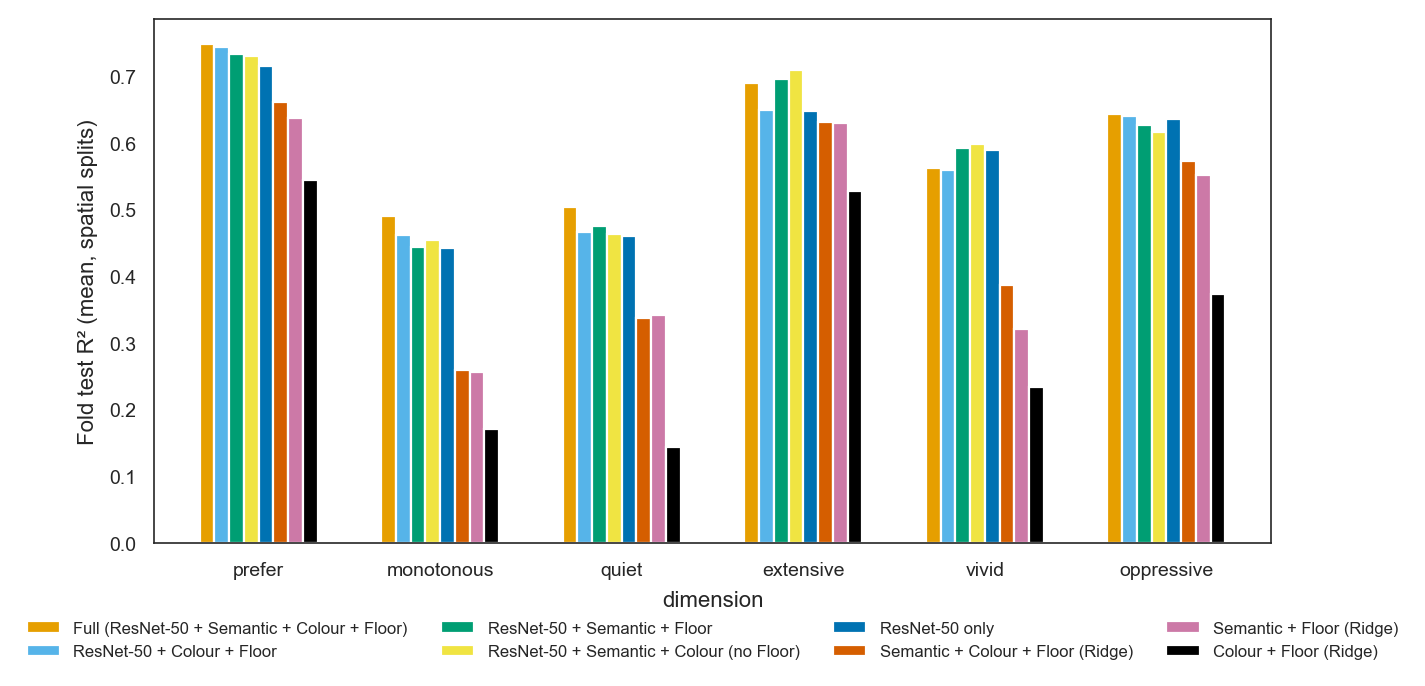

In [16]:
if "train_dimension_kfold" not in globals() or "train_tabular_ridge_kfold" not in globals():
    raise RuntimeError(
        "Run the §5 spatial K-fold training cell above first "
        "(defines train_dimension_kfold and train_tabular_ridge_kfold)."
    )

RUN_ABLATION = True
SKIP_ABLATION_IF_EXISTS = True
ABLATION_DIMS = PERCEPTION_DIMS  # or ["extensive"] for a quick test


if RUN_ABLATION:
    ablation_rows = []
    for config_key in ABLATION_TRAIN_ORDER:
        cfg = ABLATION_CONFIGS[config_key]
        if not cfg.get("train_in_ablation", True):
            out_dir = ablation_output_dir(config_key)
            summ = load_kfold_summary(out_dir)
            if summ is None:
                print(f"[{config_key}] skip train — no summary in {out_dir}; run §5 spatial K-fold first.")
                continue
            print(f"[{config_key}] merge metrics from {out_dir} (not re-trained)")
            for _, r in summ.iterrows():
                ablation_rows.append({
                    "config": config_key,
                    "label": cfg["label"],
                    "dimension": r["dimension"],
                    "test_r2_mean": r["test_r2_mean"],
                    "test_r2_std": r["test_r2_std"],
                })
            continue

        out_dir = ablation_output_dir(config_key)
        out_dir.mkdir(parents=True, exist_ok=True)
        train_fn = train_tabular_ridge_kfold if is_tabular_ridge_ablation(config_key) else train_dimension_kfold
        if SKIP_ABLATION_IF_EXISTS and ablation_config_complete(out_dir, config_key, ABLATION_DIMS):
            print(f"\n======== Ablation: {cfg['label']} ({config_key}) — skip (complete) ========", flush=True)
        else:
            print(f"\n======== Ablation: {cfg['label']} ({config_key}) ========", flush=True)
            for dim in ABLATION_DIMS:
                train_fn(
                    dim,
                    splits_dir=KFOLD_SPLITS_SPATIAL,
                    output_dir=out_dir,
                    config_key=config_key,
                    scheme_label="spatial_block",
                    skip_if_summary_exists=SKIP_ABLATION_IF_EXISTS,
                )
        summ = refresh_kfold_summary(out_dir, ABLATION_DIMS)
        for _, r in summ.iterrows():
            ablation_rows.append({
                "config": config_key,
                "label": cfg["label"],
                "dimension": r["dimension"],
                "test_r2_mean": r["test_r2_mean"],
                "test_r2_std": r["test_r2_std"],
            })

    ablation_df = pd.DataFrame(ablation_rows)
    ablation_path = MODEL_OUTPUT_ABLATION / "ablation_spatial_summary.csv"
    ablation_df.to_csv(ablation_path, index=False)
    print(f"Saved → {ablation_path}")

    plot_dims = [d for d in ABLATION_DIMS if d in ablation_df["dimension"].unique()]
    plot_configs = [c for c in ABLATION_TRAIN_ORDER if c in ablation_df["config"].unique()]
    pivot = ablation_df.pivot(index="dimension", columns="config", values="test_r2_mean")
    pivot = pivot.reindex(index=plot_dims, columns=plot_configs)
    display(pivot)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_TALL))
    prefer_r2 = pivot.loc["prefer"] if "prefer" in pivot.index else pivot.iloc[0]
    plot_configs_by_prefer = prefer_r2.sort_values(ascending=False).index.tolist()
    pivot_plot = pivot[plot_configs_by_prefer].rename(
        columns={k: ABLATION_CONFIGS[k]["label"] for k in plot_configs_by_prefer}
    )
    pivot_plot.plot(kind="bar", ax=ax, rot=0, width=0.65)
    ax.set_ylabel("Fold test R² (mean, spatial splits)")
    # ax.set_title("Pathway ablation (spatial block K-fold)")
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc="upper center",
              ncol=min(len(pivot_plot.columns), 4), fontsize=6)
    savefig_all(fig, "figures/code_4_ablation_spatial_r2")
    plt.show()


## 7. Multi-model K-fold benchmark (spatial splits)

**Run after §5–§6** (or standalone if `model_outputs/kfold_spatial/` exists).

- **Hybrid CNN**: read from `model_outputs/kfold_spatial/kfold_cv_{dim}.csv`
- **Tabular baselines**: same **spatial** frozen splits (`KFOLD_SPLITS_SPATIAL`)
- Outputs: `model_outputs/kfold_spatial/model_comparison_kfold_*`

If §5 was run in the same session, this cell also calls `show_random_vs_spatial_comparisons()` when random results exist in `kfold_random/`.


Loaded K-fold summary: model_outputs/kfold_spatial/kfold_cv_summary.csv


K-fold benchmark (5-fold test mean±std):   0%|          | 0/6 [00:00<?, ?it/s]


K-fold test R² (mean±std, 5 folds):
                            Prefer   Monotonous        Quiet    Extensive        Vivid   Oppressive
Ridge                  0.662±0.016  0.260±0.091  0.337±0.158  0.631±0.054  0.388±0.043  0.574±0.054
Lasso                  0.654±0.022  0.257±0.052  0.334±0.119  0.627±0.038  0.350±0.041  0.557±0.058
ElasticNet             0.667±0.022  0.271±0.057  0.357±0.122  0.633±0.038  0.385±0.047  0.571±0.056
PLS                    0.660±0.013  0.258±0.088  0.334±0.160  0.630±0.053  0.386±0.044  0.571±0.052
RandomForest           0.650±0.035  0.367±0.025  0.497±0.048  0.660±0.060  0.443±0.078  0.590±0.051
SVR                    0.652±0.041  0.364±0.063  0.452±0.068  0.618±0.046  0.436±0.062  0.579±0.047
XGBoost                0.628±0.033  0.267±0.046  0.470±0.032  0.592±0.073  0.426±0.064  0.568±0.037
Hybrid Neural Network  0.748±0.022  0.491±0.079  0.505±0.061  0.690±0.045  0.562±0.081  0.643±0.097

RMSE mean:
                       Prefer  Monotonous   Quiet  

split_scheme,random_stratified,spatial_block
dimension,,
prefer,0.7578,0.7482
monotonous,0.4851,0.4906
quiet,0.5047,0.5048
extensive,0.7072,0.6897
vivid,0.6281,0.5620
oppressive,0.6494,0.6434


,random − spatial
dimension,
prefer,0.0095
monotonous,-0.0055
quiet,-0.0002
extensive,0.0175
vivid,0.0661
oppressive,0.0060


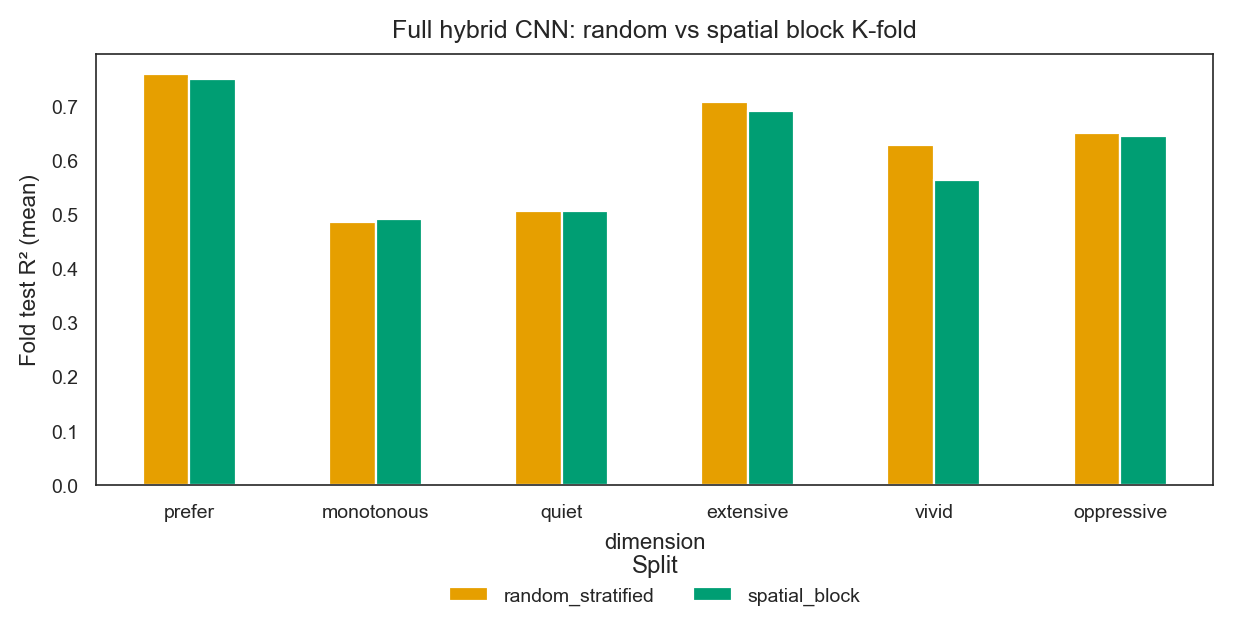


=== Multi-model benchmark — Hybrid row (random vs spatial) ===


split_scheme,random_stratified,spatial_block
dimension,,
prefer,0.7578,0.7482
monotonous,0.4851,0.4906
quiet,0.5047,0.5048
extensive,0.7072,0.6897
vivid,0.6281,0.5620
oppressive,0.6494,0.6434


,random − spatial
dimension,
prefer,0.0095
monotonous,-0.0055
quiet,-0.0002
extensive,0.0175
vivid,0.0661
oppressive,0.0060



=== Tabular + hybrid — random − spatial ΔR² (mean test R²) ===


,mean ΔR² (random−spatial)
model,
Ridge,0.0142
Lasso,0.0240
ElasticNet,0.0211
PLS,0.0139
RandomForest,0.0180
SVR,0.0069
XGBoost,0.0219
Hybrid Neural Network,0.0156


In [12]:
# --- §4 bootstrap (no §0–§3 required) ---
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from tqdm.auto import tqdm

try:
    import xgboost as xgb

    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — XGBoost row will be omitted.")

# Paths (edit MODEL_OUTPUT_DIR if your §3 checkpoints live elsewhere)
FEATURES_DIR = Path("data/training_features")
KFOLD_SPLITS_DIR = KFOLD_SPLITS_SPATIAL
MODEL_OUTPUT_DIR = MODEL_OUTPUT_SPATIAL
USE_FROZEN_KFOLD_SPLITS = True
N_FOLDS = 5
SPLIT_SEED = 42

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
PERCEPTION_DIMS_TITLE = [d.capitalize() for d in PERCEPTION_DIMS]
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})

INCH_PER_MM = 1.0 / 25.4
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_MEDIUM = 2.8


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)


def _mean_std(values) -> tuple[float, float]:
    s = pd.Series(values, dtype=float)
    return float(s.mean()), float(s.std(ddof=1))


def fmt_mean_std(mean: float, std: float, nd: int = 4) -> str:
    return f"{mean:.{nd}f}±{std:.{nd}f}"


def heatmap_mean_std_annot(mean_df: pd.DataFrame, std_df: pd.DataFrame, nd: int = 2) -> pd.DataFrame:
    """Shorter mean±std labels for heatmap cells (default 2 decimals)."""
    out = mean_df.astype(object).copy()
    for r in out.index:
        for c in out.columns:
            m, s = mean_df.loc[r, c], std_df.loc[r, c]
            if pd.notna(m):
                out.loc[r, c] = fmt_mean_std(m, s, nd=nd)
    return out


def kfold_heatmap_figsize(n_rows: int, n_cols: int) -> tuple[float, float]:
    """Scale figure size with matrix shape so cells stay readable."""
    width = max(DOUBLE_COL_WIDTH, 0.55 * n_cols + 2.0)
    height = max(3.2, 0.42 * n_rows + 1.8)
    return (width, height)


def _load_frozen_kfold_manifest(dim: str, splits_dir: Path = KFOLD_SPLITS_DIR) -> dict | None:
    path = splits_dir / f"kfold_split_{dim}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def align_frozen_kfold_folds(manifest: dict, df: pd.DataFrame) -> list[tuple[list[int], list[int], list[int]]]:
    lookup = {str(i): idx for idx, i in enumerate(df["ID"].astype(str))}
    frozen_ids = {s["ID"] for s in manifest["samples"]}
    if set(lookup) != frozen_ids:
        raise ValueError(
            f"[{manifest['dim']}] ID set mismatch vs frozen k-fold splits "
            f"(missing={len(frozen_ids - set(lookup))}, extra={len(set(lookup) - frozen_ids)})"
        )
    folds = []
    for fold in manifest["folds"]:
        tr = sorted(lookup[i] for i in fold["train_ids"])
        va = sorted(lookup[i] for i in fold["val_ids"])
        te = sorted(lookup[i] for i in fold["test_ids"])
        folds.append((tr, va, te))
    return folds


def load_training_table(dim: str) -> pd.DataFrame:
    df = pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv")
    if "ID" not in df.columns:
        raise ValueError(f"TrainingFeatures_{dim}.csv must include an ID column")
    df["ID"] = df["ID"].astype(str)
    return df


def _parse_hybrid_kfold_summary(dim: str) -> dict[str, float] | None:
    """Read §3 CNN K-fold test metrics (mean±std) from disk."""
    per_dim = MODEL_OUTPUT_DIR / f"kfold_cv_{dim}.csv"
    if per_dim.exists():
        kdf = pd.read_csv(per_dim)
        if not kdf.empty and "test_r2_mean" in kdf.columns:
            return {
                "r2_mean": float(kdf["test_r2_mean"].iloc[0]),
                "r2_std": float(kdf["test_r2_std"].iloc[0]),
                "mse_mean": float(kdf["test_mse_mean"].iloc[0]),
                "mse_std": float(kdf["test_mse_std"].iloc[0]),
                "rmse_mean": float(kdf["test_rmse_mean"].iloc[0]),
                "rmse_std": float(kdf["test_rmse_std"].iloc[0]),
            }
        if not kdf.empty and "test_r2" in kdf.columns:
            r2_m, r2_s = _mean_std(kdf["test_r2"])
            mse_m, mse_s = _mean_std(kdf["test_mse"])
            rmse_m, rmse_s = _mean_std(kdf["test_rmse"])
            return {
                "r2_mean": r2_m,
                "r2_std": r2_s,
                "mse_mean": mse_m,
                "mse_std": mse_s,
                "rmse_mean": rmse_m,
                "rmse_std": rmse_s,
            }
    summary_path = MODEL_OUTPUT_DIR / "kfold_cv_summary.csv"
    if summary_path.exists():
        sdf = pd.read_csv(summary_path)
        row = sdf.loc[sdf["dimension"] == dim]
        if not row.empty:
            r = row.iloc[0]
            return {
                "r2_mean": float(r["test_r2_mean"]),
                "r2_std": float(r["test_r2_std"]),
                "mse_mean": float(r["test_mse_mean"]),
                "mse_std": float(r["test_mse_std"]),
                "rmse_mean": float(r["test_rmse_mean"]),
                "rmse_std": float(r["test_rmse_std"]),
            }
    return None


def _build_tabular_model(name: str, n_pls: int):
    if name == "Ridge":
        return Ridge(alpha=1.0)
    if name == "Lasso":
        return Lasso(alpha=0.1)
    if name == "ElasticNet":
        return ElasticNet(alpha=0.1, l1_ratio=0.5)
    if name == "PLS":
        return PLSRegression(n_components=n_pls)
    if name == "RandomForest":
        return RandomForestRegressor(n_estimators=100, random_state=SPLIT_SEED)
    if name == "SVR":
        return SVR(kernel="rbf")
    if name == "XGBoost":
        return xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=SPLIT_SEED)
    raise ValueError(name)


TABULAR_MODEL_NAMES = [
    "Ridge",
    "Lasso",
    "ElasticNet",
    "PLS",
    "RandomForest",
    "SVR",
    "XGBoost",
]

HYBRID_MODEL_NAME = "Hybrid Neural Network"
COMPARISON_MODEL_ORDER = TABULAR_MODEL_NAMES + [HYBRID_MODEL_NAME]


def benchmark_tabular_models_kfold_for_dim(dim: str) -> dict[str, dict[str, float]]:
    """Same K-fold train/val/test splits as §3 CNN; return test metric mean±std per model."""
    df = load_training_table(dim)
    y = df[dim].values.astype(np.float64)
    feat_cols = training_aux_feature_columns(df.columns, dim)
    X = df[feat_cols].values.astype(np.float64)

    manifest = _load_frozen_kfold_manifest(dim) if USE_FROZEN_KFOLD_SPLITS else None
    if manifest is None:
        raise FileNotFoundError(
            f"Frozen splits not found: {KFOLD_SPLITS_DIR / f'kfold_split_{dim}.json'}. "
            "Set USE_FROZEN_KFOLD_SPLITS=False only if you intend to re-split live."
        )
    folds = align_frozen_kfold_folds(manifest, df)

    n_pls = min(10, X.shape[1], max(1, len(folds[0][0]) - 1))
    results: dict[str, dict[str, float]] = {}

    for name in TABULAR_MODEL_NAMES:
        if name == "XGBoost" and not HAS_XGB:
            continue
        fold_r2, fold_mse, fold_rmse = [], [], []
        for train_idx, val_idx, test_idx in folds:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X[train_idx])
            X_test = scaler.transform(X[test_idx])
            model = _build_tabular_model(name, n_pls)
            model.fit(X_train, y[train_idx])
            pred = np.asarray(model.predict(X_test), dtype=float).ravel()
            fold_r2.append(float(r2_score(y[test_idx], pred)))
            fold_mse.append(float(mean_squared_error(y[test_idx], pred)))
            fold_rmse.append(float(np.sqrt(fold_mse[-1])))
        r2_m, r2_s = _mean_std(fold_r2)
        mse_m, mse_s = _mean_std(fold_mse)
        rmse_m, rmse_s = _mean_std(fold_rmse)
        results[name] = {
            "r2_mean": r2_m,
            "r2_std": r2_s,
            "mse_mean": mse_m,
            "mse_std": mse_s,
            "rmse_mean": rmse_m,
            "rmse_std": rmse_s,
        }

    hybrid_m = _parse_hybrid_kfold_summary(dim)
    if hybrid_m is not None:
        results[HYBRID_MODEL_NAME] = hybrid_m
    else:
        print(f"[{dim}] warning: no CNN k-fold results under {MODEL_OUTPUT_DIR} — Hybrid row omitted")
    return results


# --- load §3 CNN summary once (for console) ---
_summary_p = MODEL_OUTPUT_DIR / "kfold_cv_summary.csv"
if _summary_p.exists():
    print(f"Loaded K-fold summary: {_summary_p}")
else:
    print(f"No {_summary_p.name}; will try per-dimension kfold_cv_{{dim}}.csv")

r2_mean_df = pd.DataFrame(index=COMPARISON_MODEL_ORDER, columns=PERCEPTION_DIMS_TITLE, dtype=float)
r2_std_df = r2_mean_df.copy()
mse_mean_df = r2_mean_df.copy()
mse_std_df = r2_mean_df.copy()
rmse_mean_df = r2_mean_df.copy()
rmse_std_df = r2_mean_df.copy()
r2_annot_df = pd.DataFrame(index=COMPARISON_MODEL_ORDER, columns=PERCEPTION_DIMS_TITLE, dtype=object)

for dim, col_title in tqdm(
    list(zip(PERCEPTION_DIMS, PERCEPTION_DIMS_TITLE)),
    desc=f"K-fold benchmark ({N_FOLDS}-fold test mean±std)",
):
    per_model = benchmark_tabular_models_kfold_for_dim(dim)
    for model_name, metrics in per_model.items():
        if model_name not in r2_mean_df.index:
            for d in (r2_mean_df, r2_std_df, mse_mean_df, mse_std_df, rmse_mean_df, rmse_std_df, r2_annot_df):
                d.loc[model_name] = np.nan
        r2_mean_df.loc[model_name, col_title] = metrics["r2_mean"]
        r2_std_df.loc[model_name, col_title] = metrics["r2_std"]
        mse_mean_df.loc[model_name, col_title] = metrics["mse_mean"]
        mse_std_df.loc[model_name, col_title] = metrics["mse_std"]
        rmse_mean_df.loc[model_name, col_title] = metrics["rmse_mean"]
        rmse_std_df.loc[model_name, col_title] = metrics["rmse_std"]
        r2_annot_df.loc[model_name, col_title] = fmt_mean_std(metrics["r2_mean"], metrics["r2_std"], nd=3)

filled = r2_mean_df.notna().any(axis=1)
r2_mean_df = r2_mean_df.loc[filled]
r2_std_df = r2_std_df.loc[filled]
mse_mean_df = mse_mean_df.loc[filled]
mse_std_df = mse_std_df.loc[filled]
rmse_mean_df = rmse_mean_df.loc[filled]
rmse_std_df = rmse_std_df.loc[filled]
r2_annot_df = r2_annot_df.loc[filled]

prefix = MODEL_OUTPUT_DIR / "model_comparison_kfold"
r2_mean_df.to_csv(f"{prefix}_r2_mean.csv")
r2_std_df.to_csv(f"{prefix}_r2_std.csv")
mse_mean_df.to_csv(f"{prefix}_mse_mean.csv")
mse_std_df.to_csv(f"{prefix}_mse_std.csv")
rmse_mean_df.to_csv(f"{prefix}_rmse_mean.csv")
rmse_std_df.to_csv(f"{prefix}_rmse_std.csv")

print(f"\nK-fold test R² (mean±std, {N_FOLDS} folds):")
print(r2_annot_df.to_string())
print("\nRMSE mean:")
print(rmse_mean_df.round(4).to_string())
print("\nRMSE std:")
print(rmse_std_df.round(4).to_string())
print(f"\nSaved → {prefix}_*_mean.csv / *_std.csv")

if "show_random_vs_spatial_comparisons" in globals():
    print("\n--- Random vs spatial (full hybrid + §7 benchmark) ---")
    show_random_vs_spatial_comparisons()


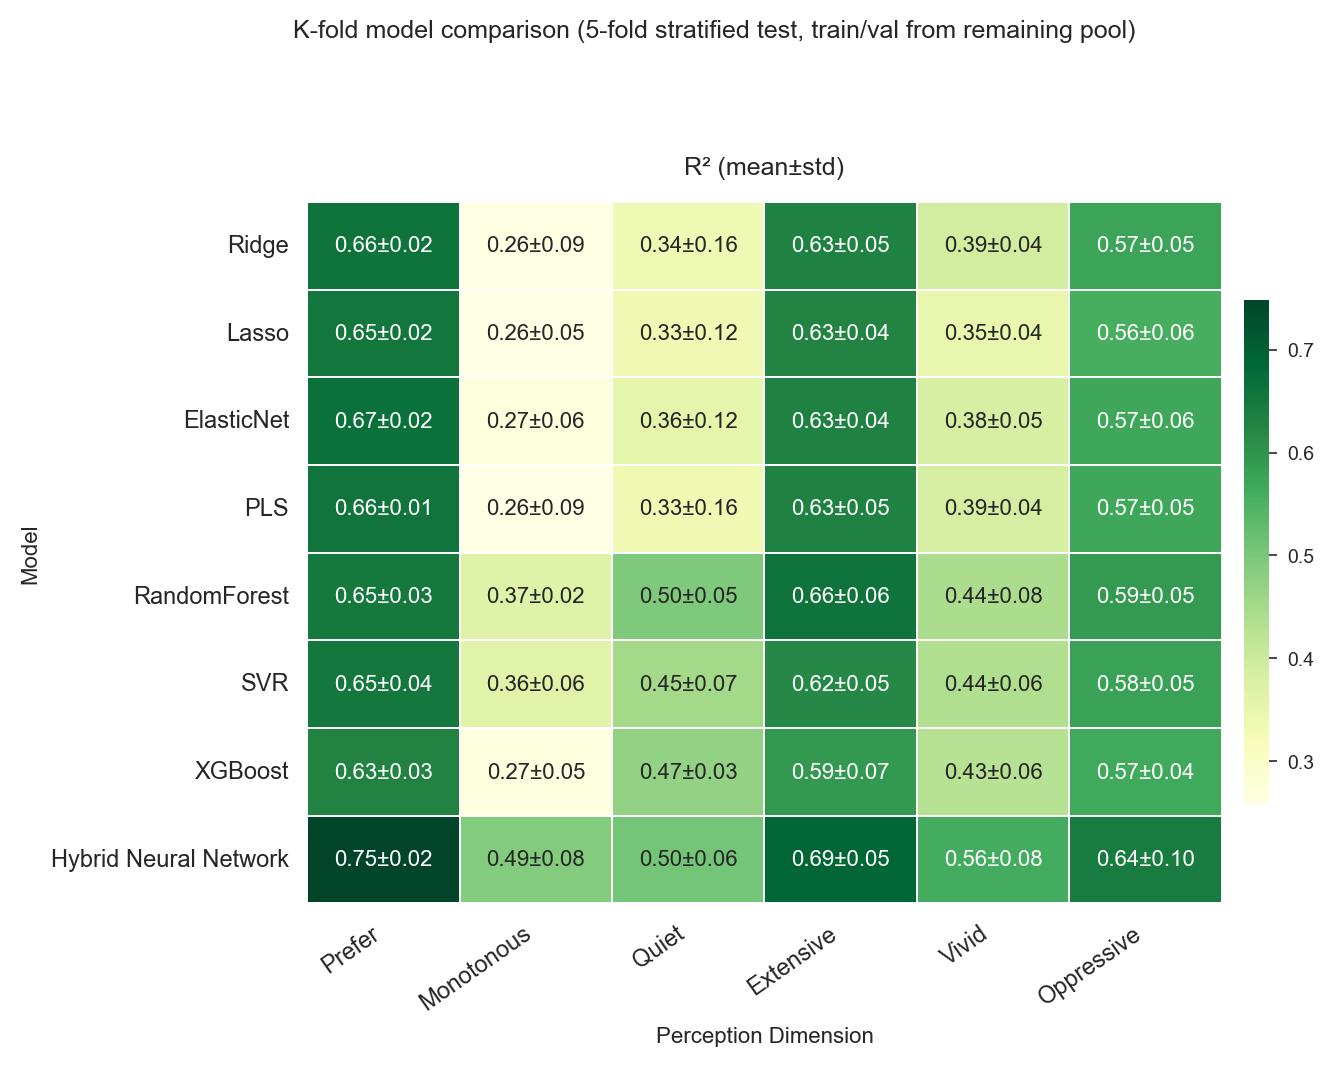

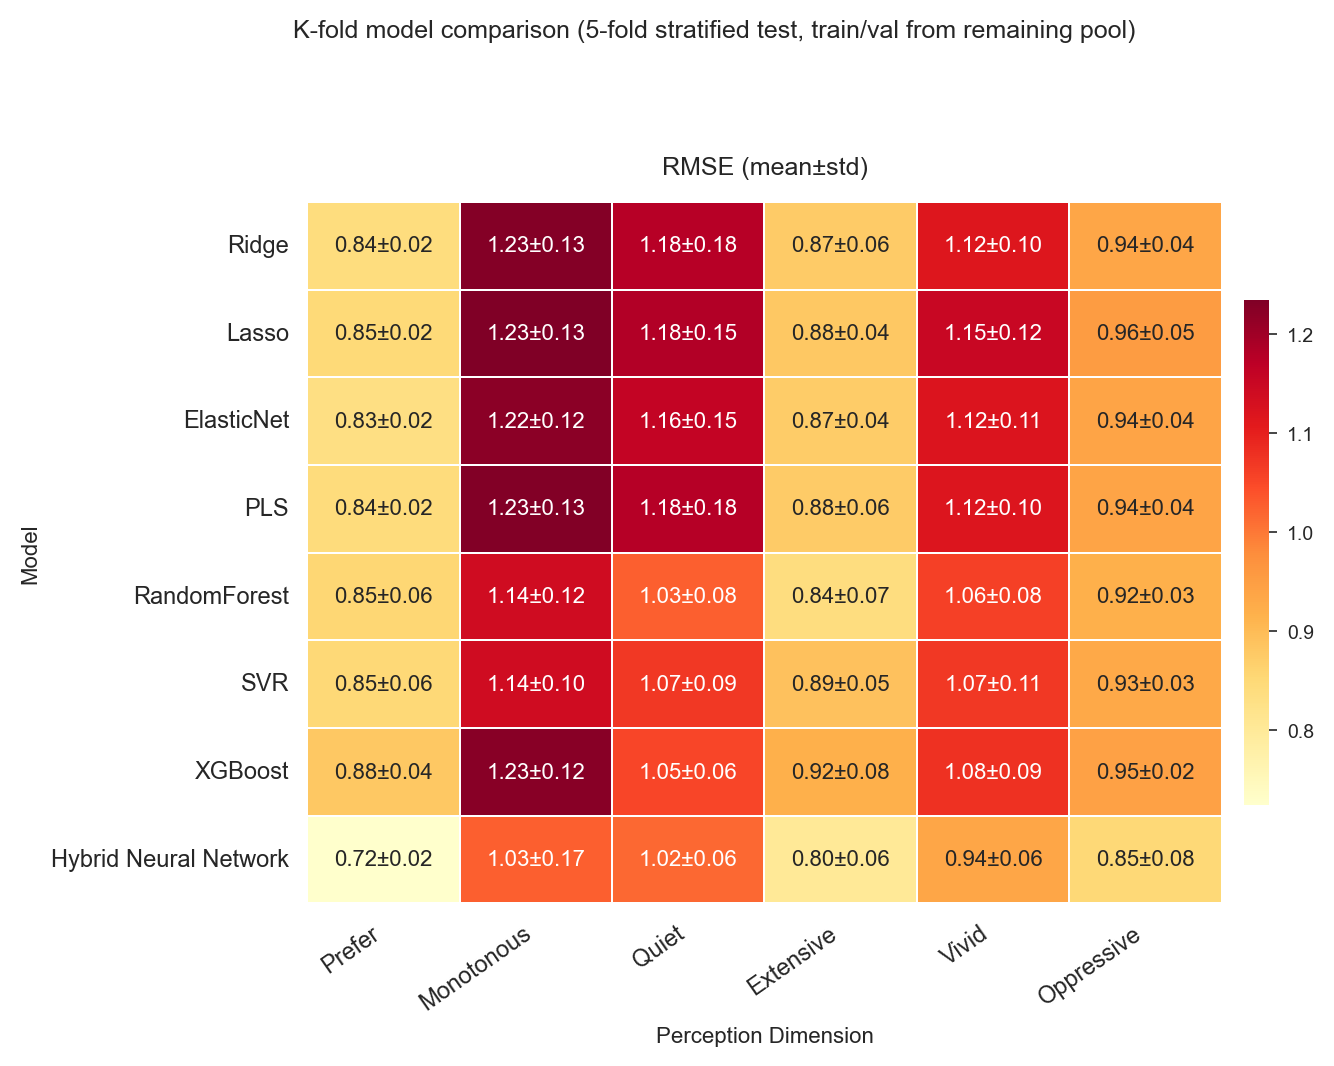

In [13]:
_kfold_subtitle = f"{N_FOLDS}-fold stratified test, train/val from remaining pool"

for mean_df, std_df, title, cmap, basename in [
    (r2_mean_df, r2_std_df, "R² (mean±std)", "YlGn", "figures/code4_model_comparison_spatial_kfold_r2_heatmap"),
    (rmse_mean_df, rmse_std_df, "RMSE (mean±std)", "YlOrRd", "figures/code4_model_comparison_spatial_kfold_rmse_heatmap"),
]:
    data = mean_df.astype(float)
    annot = heatmap_mean_std_annot(mean_df, std_df, nd=2)
    n_rows, n_cols = data.shape
    fig, ax = plt.subplots(figsize=kfold_heatmap_figsize(n_rows, n_cols))
    sns.heatmap(
        data,
        ax=ax,
        annot=annot,
        fmt="",
        cmap=cmap,
        linewidths=0.6,
        linecolor="white",
        square=False,
        annot_kws={"size": 8},
        cbar_kws={"shrink": 0.72, "pad": 0.02},
    )
    ax.set_title(title, pad=10)
    ax.set_xlabel("Perception Dimension")
    ax.set_ylabel("Model")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.tick_params(axis="x", labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)
    fig.suptitle(f"K-fold model comparison ({_kfold_subtitle})", y=1.02, fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    savefig_all(fig, basename)
    plt.show()

## 8. Reported best-model performance (spatial K-fold)

Metrics from `model_outputs/kfold_spatial/best_model_{dim}_metrics.txt` (full hybrid model, spatial block splits).


Best-checkpoint metrics (selected on validation R²):

R²:
            train_r2  val_r2  test_r2
dimension                            
prefer         0.885   0.695    0.773
monotonous     0.842   0.569    0.560
quiet          0.813   0.504    0.574
extensive      0.874   0.760    0.743
vivid          0.867   0.636    0.668
oppressive     0.872   0.710    0.739

MSE:
            train_mse  val_mse  test_mse
dimension                               
prefer         0.2435   0.5680    0.5093
monotonous     0.3526   0.8936    0.7041
quiet          0.3766   1.1658    0.8567
extensive      0.2612   0.5307    0.5185
vivid          0.2749   0.6725    0.7704
oppressive     0.2494   0.6497    0.5944

RMSE:
            train_rmse  val_rmse  test_rmse
dimension                                  
prefer          0.4934    0.7537     0.7137
monotonous      0.5938    0.9453     0.8391
quiet           0.6137    1.0797     0.9256
extensive       0.5111    0.7285     0.7201
vivid           0.5243    0.8201 

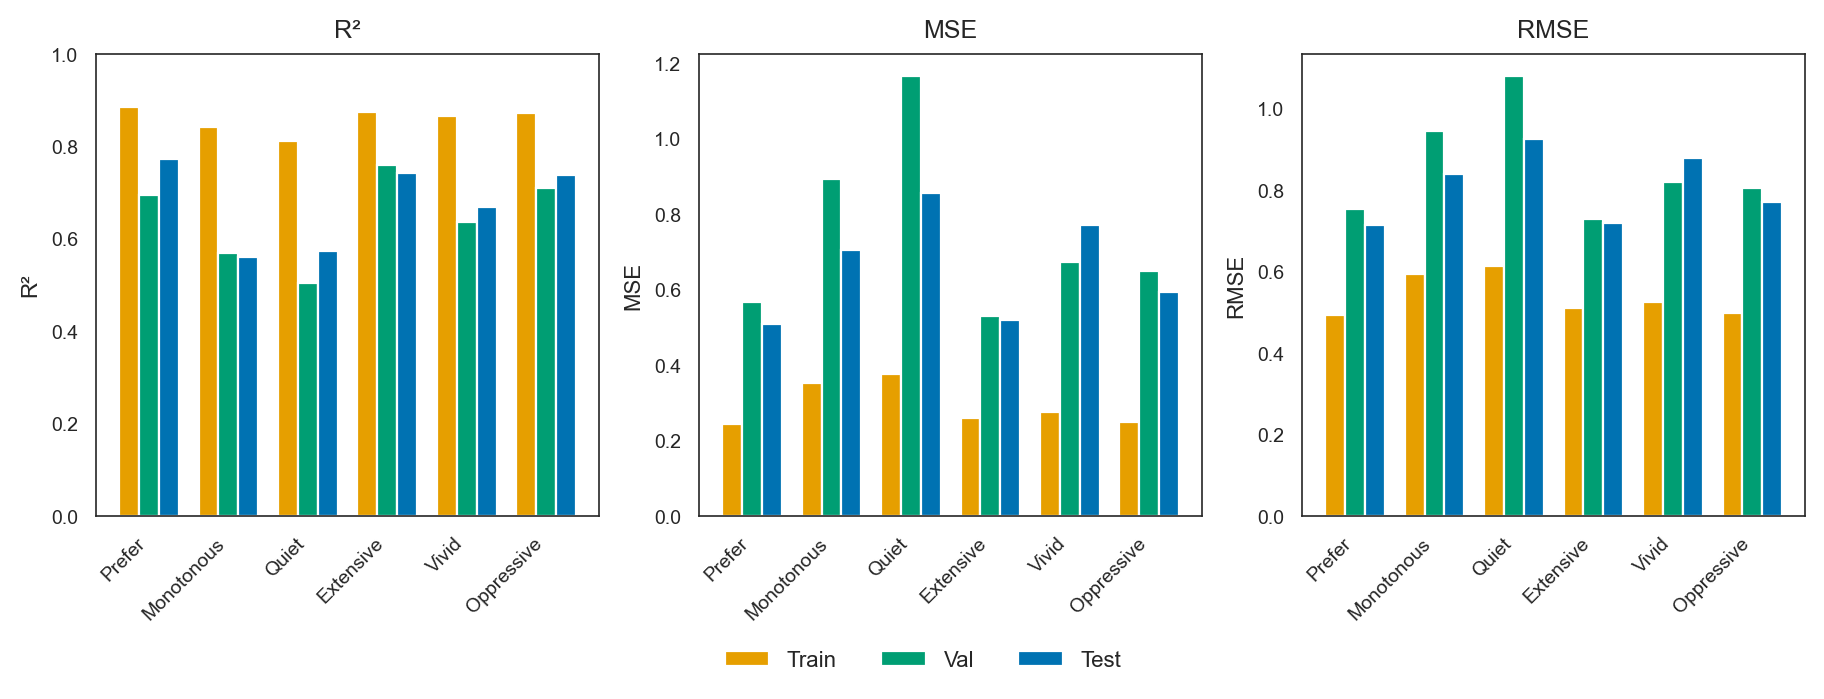

In [14]:
# --- §5 bootstrap (run after §4, or standalone) ---
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_OUTPUT_DIR = MODEL_OUTPUT_SPATIAL
PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
INCH_PER_MM = 1.0 / 25.4
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_WIDTH_WIDE = 280 * INCH_PER_MM  # wider than double column for 3-panel bar chart
FIG_HEIGHT_MEDIUM = 3.0
OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000"]


def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)


def parse_metrics_txt(p: Path) -> dict:
    text = p.read_text()
    out = {"file": p.name}
    for split in ("Train", "Validation", "Test"):
        m = re.search(
            rf"{split} - Loss: ([\d.]+), R2: ([\d.]+), MSE: ([\d.]+), MAE: ([\d.]+), RMSE: ([\d.]+)",
            text,
        )
        if m:
            key = split.lower() if split != "Validation" else "val"
            out[f"{key}_loss"] = float(m.group(1))
            out[f"{key}_r2"] = float(m.group(2))
            out[f"{key}_mse"] = float(m.group(3))
            out[f"{key}_mae"] = float(m.group(4))
            out[f"{key}_rmse"] = float(m.group(5))
    return out

rows = []
for dim in PERCEPTION_DIMS:
    p = MODEL_OUTPUT_DIR / f"best_model_{dim}_metrics.txt"
    if p.exists():
        row = parse_metrics_txt(p)
        row["dimension"] = dim
        rows.append(row)

if rows:
    perf = pd.DataFrame(rows).set_index("dimension")
    metric_cols = [
        "train_r2", "val_r2", "test_r2",
        "train_mse", "val_mse", "test_mse",
        "train_rmse", "val_rmse", "test_rmse",
    ]
    perf = perf[[c for c in metric_cols if c in perf.columns]]

    summary_path = MODEL_OUTPUT_DIR / "best_model_metrics_summary.csv"
    perf.reset_index().to_csv(summary_path, index=False)
    print("Best-checkpoint metrics (selected on validation R²):")
    print("\nR²:")
    print(perf[["train_r2", "val_r2", "test_r2"]].round(3).to_string())
    print("\nMSE:")
    print(perf[["train_mse", "val_mse", "test_mse"]].round(4).to_string())
    print("\nRMSE:")
    print(perf[["train_rmse", "val_rmse", "test_rmse"]].round(4).to_string())
    print(f"\nSaved → {summary_path}")

    fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH_WIDE, FIG_HEIGHT_MEDIUM))
    x = np.arange(len(perf.index))
    width = 0.25
    labels = [d.capitalize() for d in perf.index]

    for ax, col, title, ylabel in zip(
        axes,
        [("train_r2", "val_r2", "test_r2"), ("train_mse", "val_mse", "test_mse"), ("train_rmse", "val_rmse", "test_rmse")],
        ["R²", "MSE", "RMSE"],
        ["R²", "MSE", "RMSE"],
    ):
        ax.bar(x - width, perf[col[0]], width, color=OKABE_ITO[0], label="Train")
        ax.bar(x, perf[col[1]], width, color=OKABE_ITO[2], label="Val")
        ax.bar(x + width, perf[col[2]], width, color=OKABE_ITO[4], label="Test")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        if title == "R²":
            ax.set_ylim(0, 1)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.18))

    # fig.suptitle("Hybrid Neural Network — Best Checkpoint (stratified 60/20/20)", y=1.02, fontsize=9)
    savefig_all(fig, "figures/code_3_best_model_metrics")
    plt.show()
else:
    print(f"No metrics text files found under {MODEL_OUTPUT_DIR}.")


## 9. City-scale inference (spatial checkpoints)

Loads `model_outputs/kfold_spatial/best_model_{dim}.pth` and matching `aux_scaler_{dim}.joblib`.


In [ ]:
# --- §6 bootstrap (standalone: no §0–§5 required if checkpoints exist) ---
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm

import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

PERCEPTION_DIMS = ["prefer", "monotonous", "quiet", "extensive", "vivid", "oppressive"]
TRAINING_META_COLS = frozenset({"ID", "SampleWeight"})
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

MODEL_OUTPUT_DIR = MODEL_OUTPUT_SPATIAL
FEATURES_DIR = Path("data/training_features")
INFERENCE_IMAGES_DIR = Path("data/inference_images/WVI_Processed")
INFERENCE_FEATURES_CSV = Path("data/inference_features/Features.csv")
INFERENCE_PREDICTIONS_DIR = Path("data/inference_predictions")
TRAIN_IMG_DIR = Path("data/training_images/WVI_Processed")


def training_aux_feature_columns(columns, dim: str) -> list[str]:
    return [c for c in columns if c not in TRAINING_META_COLS and c != dim]


def list_processed_images(folder: Path) -> list[Path]:
    folder = Path(folder)
    paths: list[Path] = []
    for ext in IMAGE_EXTENSIONS:
        paths.extend(folder.glob(f"*{ext}"))
    return sorted(paths, key=lambda p: p.stem)


def reference_aux_columns(dim: str = "oppressive") -> list[str]:
    """Column order must match TrainingFeatures_{dim}.csv (24 aux features)."""
    ref = pd.read_csv(FEATURES_DIR / f"TrainingFeatures_{dim}.csv", nrows=0)
    return training_aux_feature_columns(ref.columns, dim)


class WindowSceneRegressor(nn.Module):
    def __init__(self, num_aux_features: int, dropout: float = 0.5):
        super().__init__()
        self.num_aux = num_aux_features
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        cnn_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        in_dim = cnn_dim + max(num_aux_features, 0)
        self.head = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, image, aux):
        feats = self.backbone(image)
        if self.num_aux > 0:
            feats = torch.cat((feats, aux), dim=1)
        return self.head(feats).squeeze(-1)


def load_model(num_aux_features: int) -> WindowSceneRegressor:
    return WindowSceneRegressor(num_aux_features)


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def predict_folder(
    dim: str,
    image_folder: str | Path,
    checkpoint_path: str | Path,
    aux_features_csv: str | Path,
    aux_cols: list[str] | None = None,
    device: str | None = None,
    show_progress: bool = True,
) -> pd.DataFrame:
    """Score images in `image_folder` with a trained checkpoint.

    `aux_features_csv` needs `ID` plus the same aux columns as `TrainingFeatures_{dim}.csv`.
    Supports `.jpg` and `.png` (inference WVIs are usually `.png`).
    """
    if aux_cols is None:
        aux_cols = reference_aux_columns(dim)
    device = device or (
        "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    )
    aux_df = pd.read_csv(aux_features_csv)
    aux_df["ID"] = aux_df["ID"].astype(str)
    aux_df = aux_df.drop(columns=[c for c in PERCEPTION_DIMS if c in aux_df.columns], errors="ignore")
    missing = [c for c in aux_cols if c not in aux_df.columns]
    if missing:
        raise ValueError(f"[{dim}] {aux_features_csv} missing columns: {missing}")
    aux_lookup = aux_df.set_index("ID")[aux_cols]

    n_aux = len(aux_cols)
    model = load_model(n_aux).to(device)
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    scaler_path = Path(checkpoint_path).parent / f"aux_scaler_{dim}.joblib"
    aux_scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    if aux_scaler is None:
        print(f"Warning: {scaler_path} not found — using unscaled aux features.")

    image_paths = list_processed_images(image_folder)
    iterator = tqdm(image_paths, desc=f"predict {dim}") if show_progress else image_paths
    rows = []
    for path in iterator:
        img_id = path.stem
        if img_id not in aux_lookup.index:
            continue
        image = eval_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
        aux_row = aux_lookup.loc[img_id].values.astype(np.float64).reshape(1, -1)
        if aux_scaler is not None:
            aux_row = aux_scaler.transform(aux_row)
        aux = torch.tensor(aux_row.astype(np.float32)).to(device)
        score = model(image, aux).item()
        rows.append({"ID": img_id, dim: score})
    return pd.DataFrame(rows)


RUN_CITY_INFERENCE = True  # all 6 dims on inference_images + inference_features
RUN_TRAINING_DEMO = False  # quick smoke test on training set (one dim)

if RUN_CITY_INFERENCE:
    INFERENCE_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    aux_cols = reference_aux_columns("oppressive")
    n_img = len(list_processed_images(INFERENCE_IMAGES_DIR))
    print(f"City inference: {n_img} images, {len(aux_cols)} aux features")
    for dim in PERCEPTION_DIMS:
        ckpt = MODEL_OUTPUT_DIR / f"best_model_{dim}.pth"
        if not ckpt.exists():
            print(f"  skip {dim} — missing {ckpt}")
            continue
        print(f"\n=== {dim} ===")
        preds = predict_folder(
            dim,
            INFERENCE_IMAGES_DIR,
            ckpt,
            INFERENCE_FEATURES_CSV,
            aux_cols=aux_cols,
        )
        out_path = INFERENCE_PREDICTIONS_DIR / f"predictions_{dim}.csv"
        preds.to_csv(out_path, index=False)
        print(f"  wrote {len(preds)} rows → {out_path.resolve()}")
elif RUN_TRAINING_DEMO:
    preds = predict_folder(
        "oppressive",
        TRAIN_IMG_DIR,
        MODEL_OUTPUT_DIR / "best_model_oppressive.pth",
        FEATURES_DIR / "Features.csv",
    )
    print(preds.head())
else:
    print("Set RUN_CITY_INFERENCE=True (city-scale) or RUN_TRAINING_DEMO=True (smoke test).")

## 10. (Optional) Grad‑CAM Visual Saliency

When interpretability is needed, Grad‑CAM highlights which image regions most influenced the predicted score.  The snippet below is provided for reference; it is not executed by default.


In [ ]:
GRADCAM_CODE = '''
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

def saliency_overlay(model, image_path, target_layer="backbone.layer4.2.conv3"):
    model.eval()
    cam = GradCAM(model, target_layer)
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).requires_grad_(True)
    out = model(x, torch.zeros(1, model.head[0].in_features - 2048))
    activation_map = cam(0, out)
    if isinstance(activation_map, list):
        activation_map = torch.stack(activation_map).mean(0)
    return overlay_mask(to_pil_image(x.squeeze(0)), to_pil_image(activation_map.squeeze(), mode="F"), alpha=0.5)
'''
print(GRADCAM_CODE.strip())

from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

def saliency_overlay(model, image_path, target_layer="backbone.layer4.2.conv3"):
    model.eval()
    cam = GradCAM(model, target_layer)
    img = Image.open(image_path).convert("RGB")
    x = eval_transform(img).unsqueeze(0).requires_grad_(True)
    out = model(x, torch.zeros(1, model.head[0].in_features - 2048))
    activation_map = cam(0, out)
    if isinstance(activation_map, list):
        activation_map = torch.stack(activation_map).mean(0)
    return overlay_mask(to_pil_image(x.squeeze(0)), to_pil_image(activation_map.squeeze(), mode="F"), alpha=0.5)


**Summary.** Code 4 compares random vs spatial K-fold splits, trains the hybrid CNN on **spatial** folds (`model_outputs/kfold_spatial/`), runs pathway **ablations** on the same splits, benchmarks tabular models, and scores the city-wide WVI set. Random-split checkpoints are kept under `model_outputs/kfold_random/` for comparison only.
